# Assignment 10: LSTM for Weather Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv('DailyDelhiClimateTrain.csv')

df = df[['meantemp']]
df.head()

,meantemp
0,10.000000
1,7.400000
2,7.166667
3,8.666667
4,6.000000


In [3]:
train_size = int(len(df) * 0.8)

train_data = df[:train_size]
test_data = df[train_size:]

In [4]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [5]:
def create_dataset(data, window=30):
    X, y = [], []
    
    for i in range(window, len(data)):
        X.append(data[i-window:i, 0])
        y.append(data[i, 0])
    
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_scaled)
X_test, y_test = create_dataset(test_scaled)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [6]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(LSTM(50))

model.add(Dense(1))

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [8]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0526
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0070
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0053
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0052
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0051
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0049
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0049
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0047
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0046
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0046


In [9]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


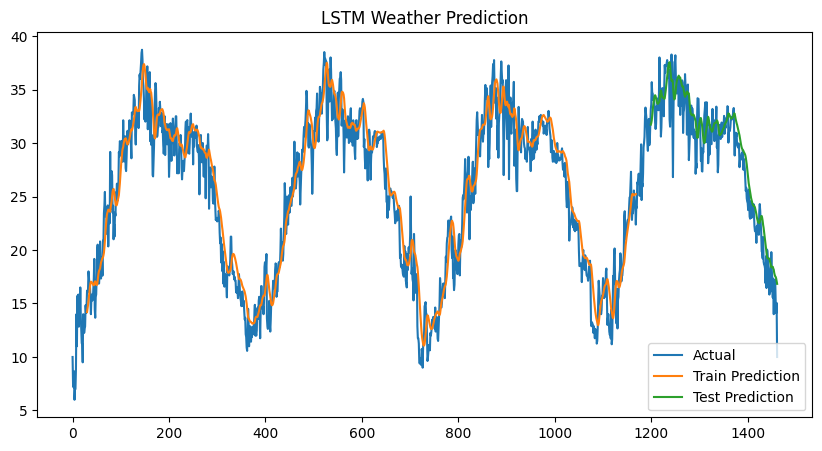

In [10]:
plt.figure(figsize=(10,5))

plt.plot(df.values, label='Actual')

plt.plot(range(30, len(train_pred)+30), train_pred, label='Train Prediction')

plt.plot(range(len(train_pred)+60, len(train_pred)+60+len(test_pred)), test_pred, label='Test Prediction')

plt.legend()
plt.title("LSTM Weather Prediction")

plt.show()

In [11]:
last_30 = test_scaled[-30:]

future = []

current_input = last_30.reshape(1,30,1)

for i in range(7):
    
    pred = model.predict(current_input)[0][0]
    future.append(pred)
    
    current_input = np.append(current_input[:,1:,:], [[[pred]]], axis=1)

future = scaler.inverse_transform(np.array(future).reshape(-1,1))

print("Next 7 Days Temperature Prediction:")
print(future)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Next 7 Days Temperature Prediction:
[[16.280102 ]
 [15.991055 ]
 [15.842768 ]
 [15.790064 ]
 [15.8012705]
 [15.854981 ]
 [15.935999 ]]
